In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plot_opts, utils
plt.rcParams.update(plot_opts.params)

In [2]:
resolution = 0.02
mode = "galvanostatic"
name_of_study = "reaction_distribution"
mesh_folder = f"output/{name_of_study}/20-20-80/{resolution}/{mode}"
figures_dir = os.path.join('figures', *mesh_folder.split("/")[1:])
utils.make_dir_if_missing(figures_dir)
n_procs = 2

In [3]:
def get_input_dir(Wa, Kr, gamma, n_procs=n_procs):
    return os.path.join(mesh_folder, f'butler_volmer/0.001-{Wa}-{Kr}/1.0C/1-4/{gamma}/{n_procs}')

In [4]:
results = []
Wa_test = [0.01, 0.1, 1.0, 10.0, 100.0]
Kr_test = [0.01, 0.1, 1.0, 10.0, 100.0]
for Wa in Wa_test:
    for Kr in Kr_test:
        results_file_json = os.path.join(get_input_dir(Wa, Kr, gamma=0.01), "simulation.json")
        if not os.path.isfile(results_file_json):
            results_file_json = os.path.join(get_input_dir(Wa, Kr, gamma=0.1), "simulation.json")
        if os.path.isfile(results_file_json):
            with open(results_file_json, "r") as fp:
                results_row = json.load(fp)
                if results_row.get("i (stdev) se/am [A/m2]") is not None:
                    results.append(results_row)
        else:
            print(f"{results_file_json} not found")

output/reaction_distribution/20-20-80/0.02/galvanostatic/butler_volmer/0.001-10.0-100.0/1.0C/1-4/0.1/2/simulation.json not found
output/reaction_distribution/20-20-80/0.02/galvanostatic/butler_volmer/0.001-100.0-100.0/1.0C/1-4/0.1/2/simulation.json not found


In [5]:
data = pd.DataFrame(results)

In [6]:
# Normalized stdev of current density at SE/AM interface
df_left = data[['Positive Wa', 'Kr', 'i (avg) left [A/m2]', 'i (stdev) left [A/m2]']]
df_se_am = data[['Positive Wa', 'Kr', 'i (avg) se/am [A/m2]', 'i (stdev) se/am [A/m2]', 'i (avg) right [A/m2]']]
df_right = data[['Positive Wa', 'Kr', 'i (avg) right [A/m2]', 'i (stdev) right [A/m2]']]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


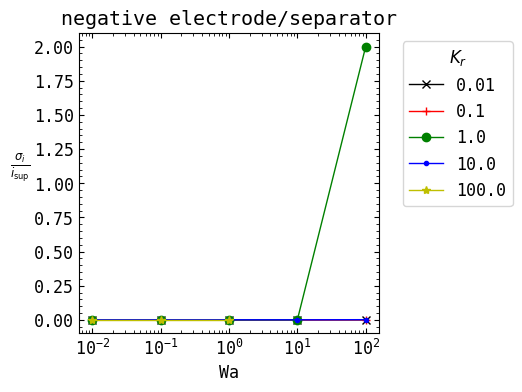

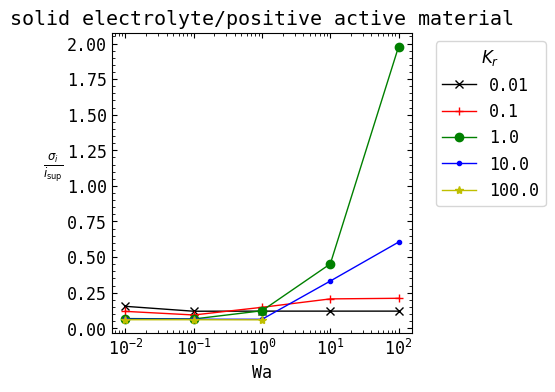

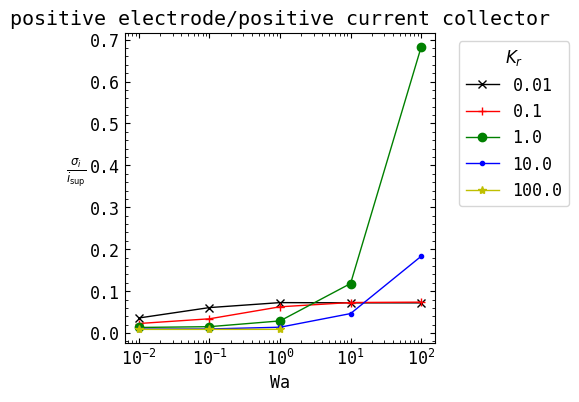

In [7]:
fig, ax = plt.subplots()
styles = ['kx-', 'r+-', 'go-', 'b.-', 'y*-', 'bx--', 'k*--', 'r+--', 'bx--', 'y+--']
for idx, Kr in enumerate(Kr_test):
    df_left_ = df_left[np.isclose(df_left['Kr'], Kr)]
    ax.semilogx(df_left_['Positive Wa'], df_left_['i (stdev) left [A/m2]'] / np.abs(df_left_['i (avg) left [A/m2]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylabel(r'$\frac{\sigma_{i}}{i_{\mathrm{sup}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
# ax.set_ylim([0, 2.5])
ax.set_title('negative electrode/separator')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_stdev_norm_left_by_wa'), format='eps')

fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_se_am_ = df_se_am[np.isclose(df_se_am['Kr'], Kr)]
    ax.plot(df_se_am_['Positive Wa'], df_se_am_['i (stdev) se/am [A/m2]'] / np.abs(df_se_am_['i (avg) right [A/m2]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
# ax.set_ylabel(r'$\frac{\sigma_{i_n}}{\mu_{i_n}}$', rotation=0, labelpad=10)
ax.set_ylabel(r'$\frac{\sigma_{i}}{i_{\mathrm{sup}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_ylim([0.1, 100])
ax.set_title('solid electrolyte/positive active material')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_stdev_norm_se_am_by_wa.eps'), format='eps')

fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_right_ = df_right[np.isclose(df_right['Kr'], Kr)]
    ax.semilogx(df_right_['Positive Wa'], df_right_['i (stdev) right [A/m2]'] / np.abs(df_right_['i (avg) right [A/m2]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
# ax.set_ylabel(r'$\frac{\sigma_{i_n}}{\mu_{i_n}}$', rotation=0, labelpad=10)
ax.set_ylabel(r'$\frac{\sigma_{i}}{i_{\mathrm{sup}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.set_title('positive electrode/positive current collector')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_stdev_norm_right_by_wa.eps'), format='eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


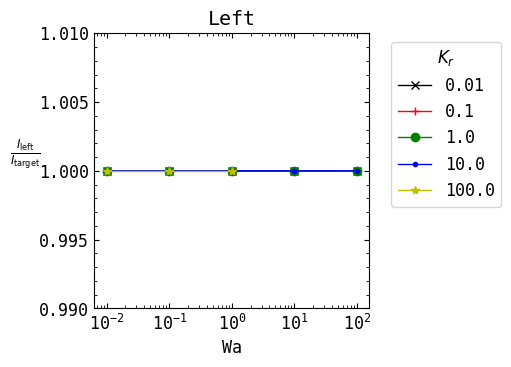

In [8]:
df_0 = data[['Positive Wa', 'Kr', 'I left [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_0_ = df_0[np.isclose(df_0['Kr'], Kr)]
    ax.semilogx(df_0_['Positive Wa'], np.abs(df_0_['I left [A]'] / df_0_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
ax.set_ylim([0.99, 1.01])
ax.set_ylabel(r'$\frac{I_{\mathrm{left}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax.set_title('Left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_error_left_by_wa.eps'), format='eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


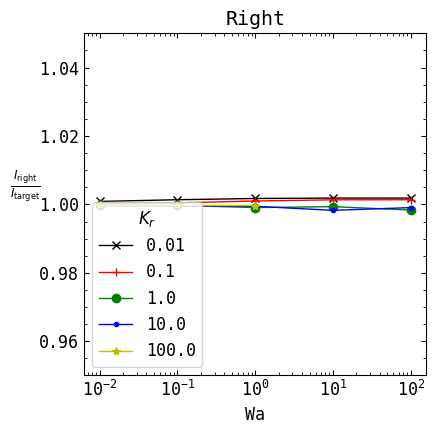

In [9]:
df_2 = data[['Positive Wa', 'Kr', 'I right [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_2_ = df_2[np.isclose(df_2['Kr'], Kr)]
    ax.semilogx(df_2_['Positive Wa'], np.abs(df_2_['I right [A]'] / df_2_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.set_box_aspect(1)
# ax.axhline(y=0.95, color='gray', linestyle='--')
# ax.axhline(y=1.05, color='gray', linestyle='--')
ax.set_ylim([0.95, 1.05])
ax.set_ylabel(r'$\frac{I_{\mathrm{right}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', loc='lower left')
ax.set_title("Right")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_error_right_by_wa.eps'), format='eps')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


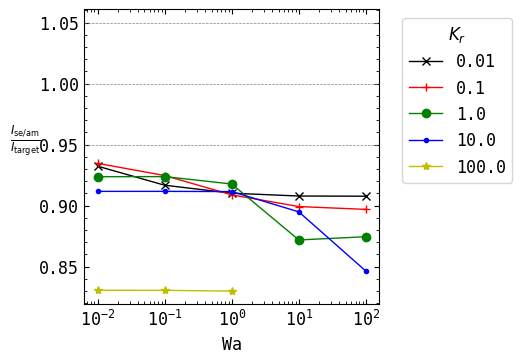

In [10]:
df_1 = data[['Positive Wa', 'Kr', 'I interface [A]', 'I (target) right [A]']]
fig, ax = plt.subplots()
for idx, Kr in enumerate(Kr_test):
    df_1_ = df_1[np.isclose(df_1['Kr'], Kr)]
    ax.semilogx(df_1_['Positive Wa'], np.abs(df_1_['I interface [A]'] / df_1_['I (target) right [A]']), styles[idx], label=f'{Kr}')
ax.axhline(y=0.95, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.5)
ax.axhline(y=1.05, color='gray', linestyle='--', linewidth=0.5)
ax.set_box_aspect(1)
ax.set_ylabel(r'$\frac{I_{\mathrm{se/am}}}{I_{\mathrm{target}}}$', rotation=0, labelpad=10)
ax.set_xlabel('Wa')
ax.legend(title='$K_r$', bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'i_error_se_am_by_wa.eps'), format='eps')